In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('../datasets/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(df.shape)
print()
print(df.info())

(891, 12)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [5]:
# separate columns

numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()

print(f"Numerical: {numerical_cols}")
print(f"Categorical: {categorical_cols}")

#m missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %' : missing_pct}))

Numerical: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


In [6]:
# extract deck from cabin
df['Deck'] = df['Cabin'].str[0] # first letter = deck
df['Deck'] = df['Deck'].fillna('Unknown')

print(df['Deck'].value_counts())

# drop useless columns
df = df.drop(columns = ['PassengerId', 'Name', 'Ticket', 'Cabin'])
print(f'\nRemaining columns: {df.columns.tolist()}')

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Deck']


In [7]:
from sklearn.impute import SimpleImputer

# imputing missing values with the most frequent
imputer = SimpleImputer(strategy='most_frequent')
df['Embarked'] = imputer.fit_transform(df[['Embarked']])[:, 0]

print(df['Embarked'].value_counts())
print(df['Embarked'].isnull().sum())  # should be 0

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64
0


In [8]:
# creating Family feature (we'll binarize this later)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print(df['FamilySize'].value_counts())
print()
print(df['IsAlone'].value_counts())

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

IsAlone
1    537
0    354
Name: count, dtype: int64


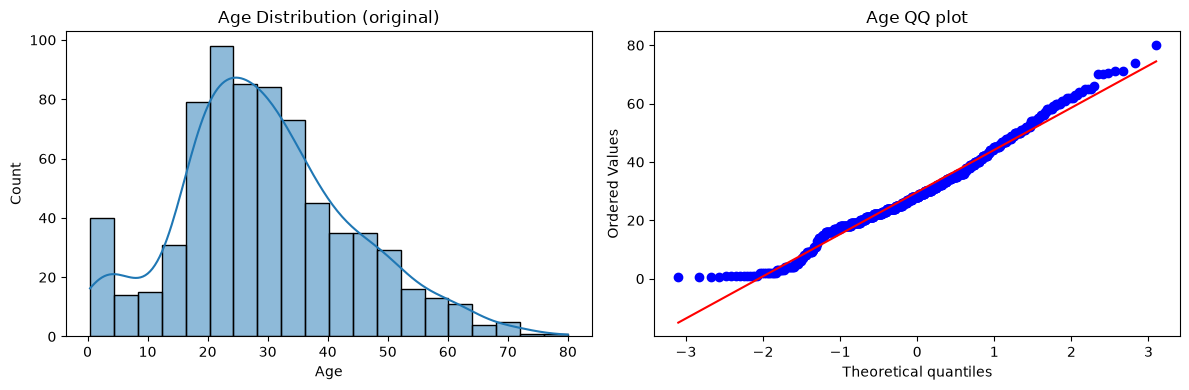

Skewness: 0.39
Missing: 177


In [9]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['Age'].dropna(), kde=True)
plt.title('Age Distribution (original)')

plt.subplot(1,2,2)
stats.probplot(df['Age'].dropna(), dist='norm', plot=plt)
plt.title("Age QQ plot")

plt.tight_layout()
plt.show()

print(f"Skewness: {df['Age'].skew():.2f}")
print(f'Missing: {df["Age"].isnull().sum()}')

In [10]:
# creating columns for differnet imputation to see which is best
df['Age_mean'] = df['Age']
df['Age_median'] = df['Age']
df['Age_random'] = df['Age']
df['Age_EOD'] = df['Age']

print('Copies created')
print(df[['Age', 'Age_mean', 'Age_median', 'Age_random', "Age_EOD"]].isnull().sum())

Copies created
Age           177
Age_mean      177
Age_median    177
Age_random    177
Age_EOD       177
dtype: int64


In [11]:
from sklearn.impute import SimpleImputer

# 1. Mean imputation
mean_imputer = SimpleImputer(strategy = 'mean')
df['Age_mean'] = mean_imputer.fit_transform(df[['Age']])[:,0]

# 2. Median imputation
median_imputer = SimpleImputer(strategy='median')
df['Age_median'] = median_imputer.fit_transform(df[['Age']])[:, 0]

# 3. End of distribution
eod_value = df['Age'].mean() + 3 * df['Age'].std()
eod_imputer = SimpleImputer(strategy='constant', fill_value=eod_value)
df['Age_EOD'] = eod_imputer.fit_transform(df[['Age']])[:, 0]

# 4. Random sample — no sklearn built-in, manual is fine here
np.random.seed(42)
random_samples = df['Age'].dropna().sample(
    df['Age'].isnull().sum(),
    random_state=42
).values
df.loc[df['Age_random'].isnull(), 'Age_random'] = random_samples

# verify
print(df[['Age_mean', 'Age_median', 'Age_random', 'Age_EOD']].isnull().sum())

Age_mean      0
Age_median    0
Age_random    0
Age_EOD       0
dtype: int64


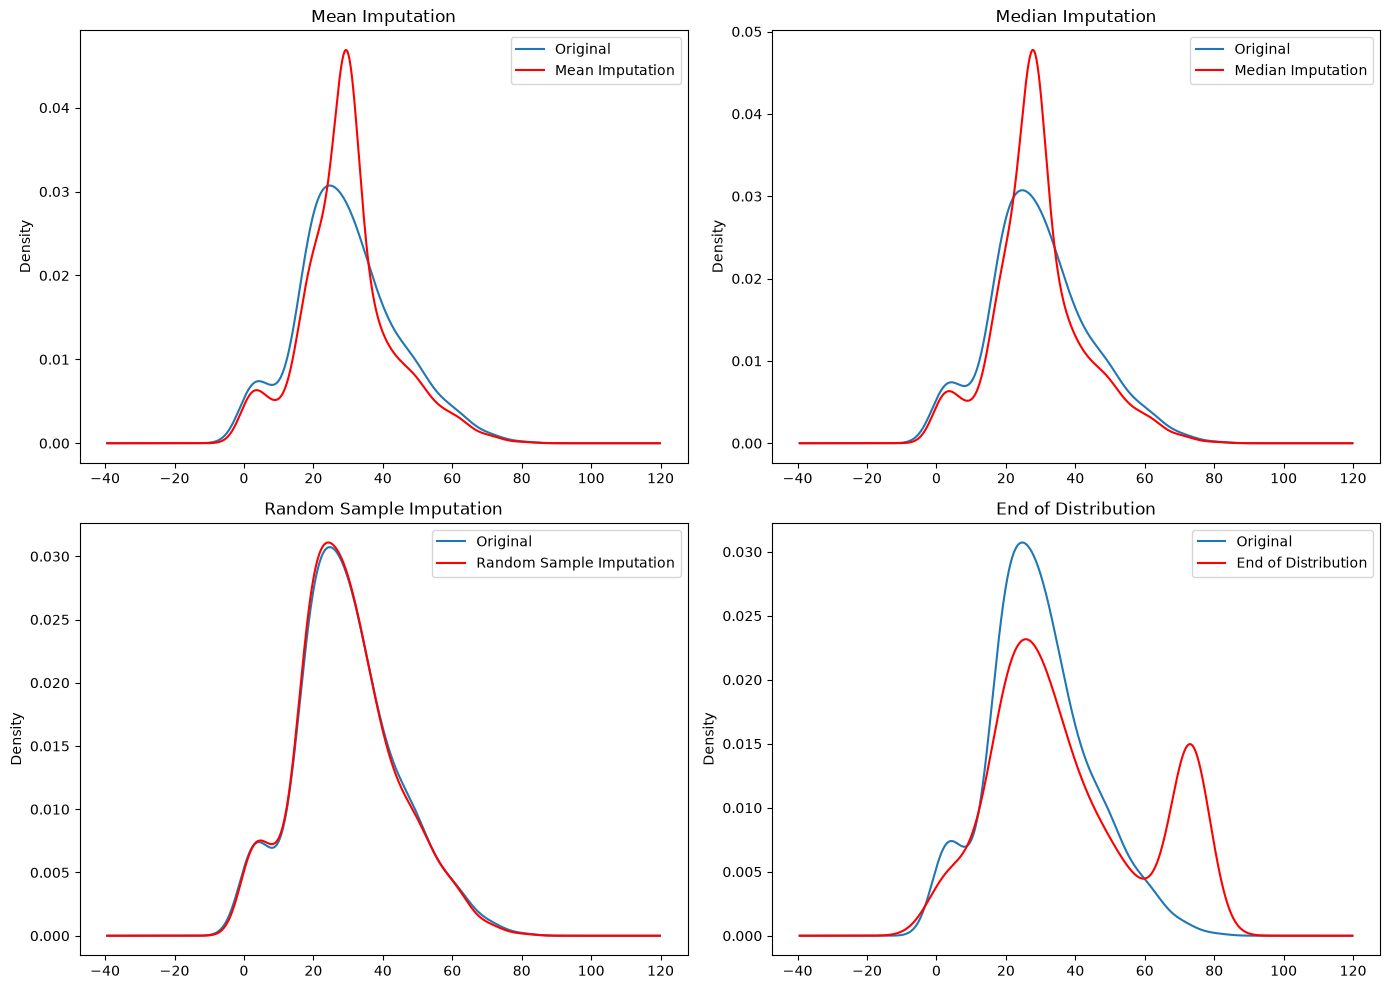

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cols = ['Age_mean', 'Age_median', 'Age_random', 'Age_EOD']
titles = ['Mean Imputation', 'Median Imputation', 
          'Random Sample Imputation', 'End of Distribution']

for ax, col, title in zip(axes.flatten(), cols, titles):
    ax.set_title(title)
    df['Age'].plot(kind='kde', ax=ax, label='Original')
    df[col].plot(kind='kde', ax=ax, label=title, color='red')
    ax.legend()

plt.tight_layout()
plt.show()

Only the random imputation perfectly overlaps the blue and doesn't distorts the original distribution.
All other imputations distorts the original distribution.

In [13]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice_imputer = IterativeImputer(max_iter=10, random_state = 42)

# MICE uses ALL columns to predict Age
df_mice = df[['Age','Pclass', 'SibSp', 'Parch', 'Fare']].copy()
df['Age_MICE'] = mice_imputer.fit_transform(df_mice)[:,0]

print(f"Missing after MICE: {df['Age_MICE'].isnull().sum()}")

Missing after MICE: 0


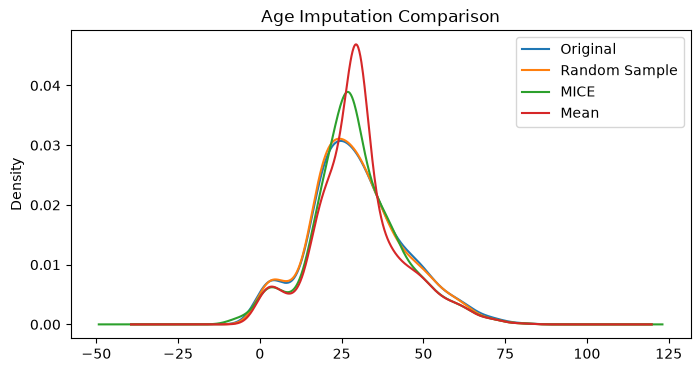

In [14]:
plt.figure(figsize=(8, 4))

df['Age'].plot(kind='kde', label='Original')
df['Age_random'].plot(kind='kde', label='Random Sample')
df['Age_MICE'].plot(kind='kde', label='MICE')
df['Age_mean'].plot(kind='kde', label='Mean')

plt.title('Age Imputation Comparison')
plt.legend()
plt.show()

Missing after KNN: 0


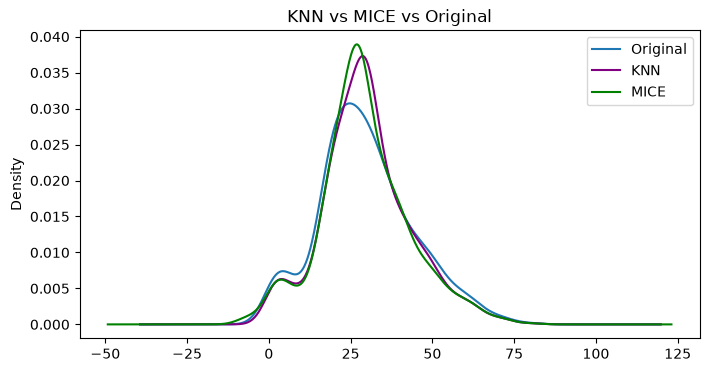

In [15]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)

df_knn = df[['Age', 'Pclass', 'SibSp', 'Parch', 'Fare']].copy()
df['Age_KNN'] = knn_imputer.fit_transform(df_knn)[:, 0]

print(f'Missing after KNN: {df["Age_KNN"].isnull().sum()}')

# compare with original
plt.figure(figsize=(8,4))
df['Age'].plot(kind='kde', label='Original')
df['Age_KNN'].plot(kind='kde', label='KNN', color='purple')
df['Age_MICE'].plot(kind='kde', label='MICE', color='green')
plt.title('KNN vs MICE vs Original')
plt.legend()
plt.show()

since KNN imputer gives almost same distribution and it also uses features relationships we will keep it.

on the other hand the random imputer perfectly matches the distribution but the values are chosen randomly from the existing values and has no feature relationships so we're not gonna use it

In [16]:
# keep KNN imputed Age
df['Age'] = df['Age_KNN']

# drop comparison columns
df = df.drop(columns=['Age_mean', 'Age_median', 'Age_random', 
                       'Age_EOD', 'Age_MICE', 'Age_KNN'])

print(f'Missing Age: {df["Age"].isnull().sum()}')
print(f'Columns: {df.columns.tolist()}')

Missing Age: 0
Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Deck', 'FamilySize', 'IsAlone']


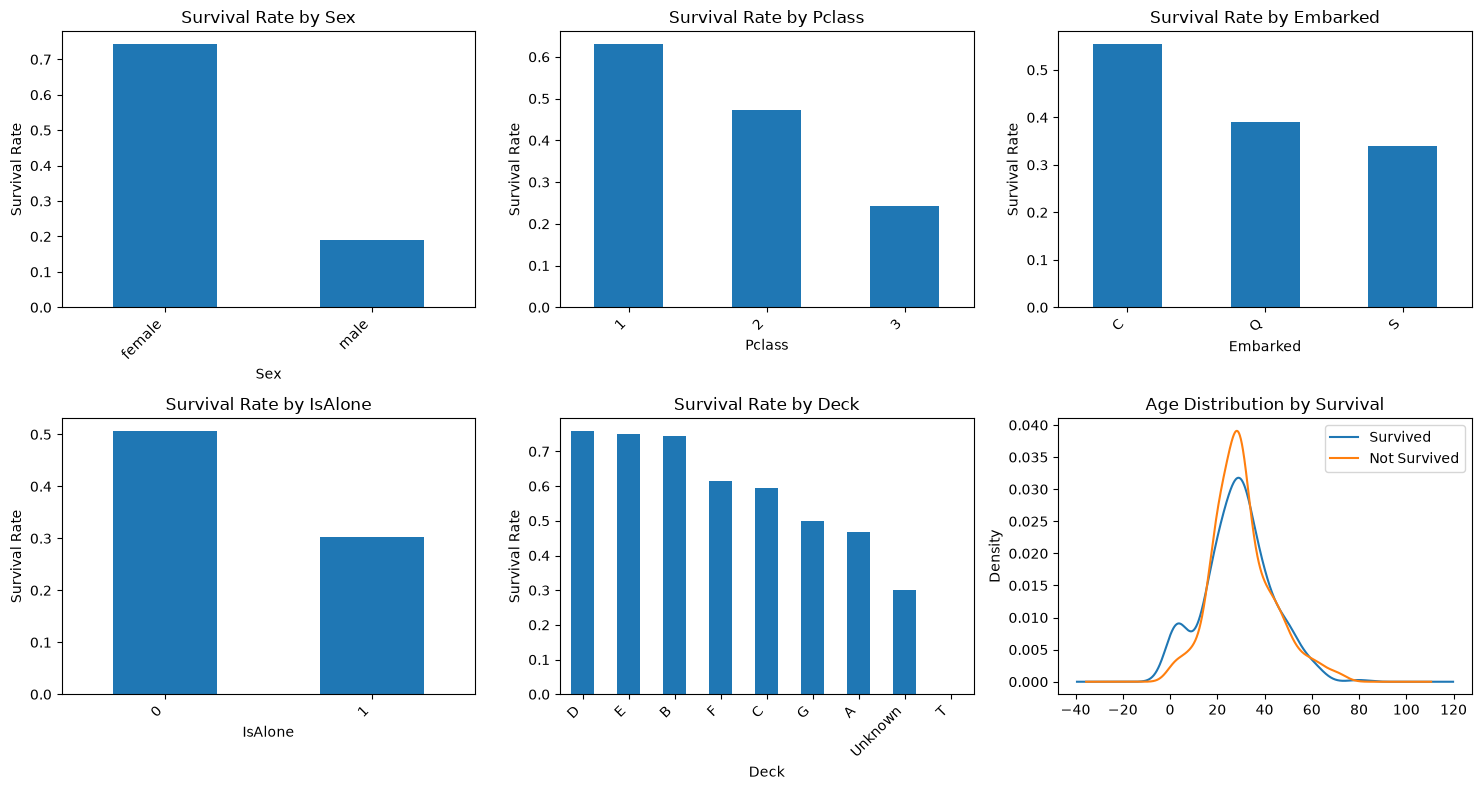

In [17]:
cat_features = ['Sex', 'Pclass', 'Embarked', 'IsAlone', 'Deck']

plt.figure(figsize=(15, 8))
for i, col in enumerate(cat_features):
    plt.subplot(2, 3, i+1)
    df.groupby(col)['Survived'].mean().sort_values(ascending=False).plot(kind='bar')
    plt.title(f'Survival Rate by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Survival Rate')

# age distribution by survival — different type so outside loop
plt.subplot(2, 3, 6)
df[df['Survived']==1]['Age'].plot(kind='kde', label='Survived')
df[df['Survived']==0]['Age'].plot(kind='kde', label='Not Survived')
plt.title('Age Distribution by Survival')
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(f"X_train:{X_train.shape}")
print(f"X_test: {X_test.shape}")

X_train:(712, 10)
X_test: (179, 10)


In [19]:
X_train


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,FamilySize,IsAlone
692,3,male,29.6,0,0,56.4958,S,Unknown,1,1
481,2,male,32.2,0,0,0.0000,S,Unknown,1,1
527,1,male,30.8,0,0,221.7792,S,C,1,1
855,3,female,18.0,0,1,9.3500,S,Unknown,2,0
801,2,female,31.0,1,1,26.2500,S,Unknown,3,0
...,...,...,...,...,...,...,...,...,...,...
359,3,female,30.4,0,0,7.8792,Q,Unknown,1,1
258,1,female,35.0,0,0,512.3292,C,Unknown,1,1
736,3,female,48.0,1,3,34.3750,S,Unknown,5,0
462,1,male,47.0,0,0,38.5000,S,E,1,1


In [20]:
def categorize_family(size):
    if size == 1:
        return 'alone'
    elif size <= 4:
        return 'small'
    else:
        return 'large'

In [21]:
X_train['FamilyGroup'] = X_train['FamilySize'].map(categorize_family)
X_test['FamilyGroup'] = X_test['FamilySize'].map(categorize_family)

print(X_train['FamilyGroup'].value_counts())

FamilyGroup
alone    434
small    228
large     50
Name: count, dtype: int64


In [28]:
import numpy as np

def categorize_family_array(X):
    X = np.array(X).flatten()  # ensure it's a 1D array regardless of input
    result = []
    for size in X:
        result.append(categorize_family(size))
    return np.array(result)

transformer.fit_transform(X_train[['FamilySize']])  # fit + transform train
transformer.transform(X_test[['FamilySize']])        # just transform test

array(['small', 'small', 'alone', 'small', 'small', 'small', 'alone',
       'alone', 'small', 'small', 'alone', 'small', 'alone', 'small',
       'large', 'alone', 'large', 'alone', 'alone', 'alone', 'alone',
       'small', 'alone', 'small', 'alone', 'alone', 'alone', 'small',
       'alone', 'alone', 'alone', 'alone', 'small', 'alone', 'small',
       'small', 'small', 'large', 'alone', 'small', 'small', 'small',
       'alone', 'alone', 'alone', 'alone', 'alone', 'small', 'small',
       'alone', 'alone', 'alone', 'alone', 'alone', 'small', 'alone',
       'small', 'alone', 'alone', 'alone', 'small', 'small', 'alone',
       'alone', 'small', 'small', 'small', 'alone', 'alone', 'alone',
       'small', 'alone', 'small', 'alone', 'alone', 'small', 'alone',
       'small', 'large', 'large', 'large', 'alone', 'alone', 'alone',
       'alone', 'small', 'alone', 'small', 'alone', 'small', 'alone',
       'alone', 'alone', 'alone', 'small', 'alone', 'alone', 'alone',
       'alone', 'alo

In [29]:
X_train['Deck'].value_counts()

Deck
Unknown    552
C           41
B           34
E           29
D           26
A           14
F           11
G            4
T            1
Name: count, dtype: int64

In [30]:
# step 1 — learn from train only
most_frequent_deck = X_train['Deck'][X_train['Deck'] != 'Unknown'].mode()[0]
print(most_frequent_deck)

C


In [31]:
def impute_frequent_deck(X):
    X = np.array(X).flatten()
    return np.where(X == 'Unknown', most_frequent_deck, X)

In [34]:
deck_imputer = FunctionTransformer(impute_frequent_deck)
result = deck_imputer.fit_transform(X_train[['Deck']])
print(np.unique(result))  # 'Unknown' should be gone

['A' 'B' 'C' 'D' 'E' 'F' 'G' 'T']


In [35]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,Unknown,2,0
1,1,1,female,38.0,1,0,71.2833,C,C,2,0
2,1,3,female,26.0,0,0,7.9250,S,Unknown,1,1
3,1,1,female,35.0,1,0,53.1000,S,C,2,0
4,0,3,male,35.0,0,0,8.0500,S,Unknown,1,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Unknown,1,1
887,1,1,female,19.0,0,0,30.0000,S,B,1,1
888,0,3,female,26.8,1,2,23.4500,S,Unknown,4,0
889,1,1,male,26.0,0,0,30.0000,C,C,1,1


In [36]:
print(X_train.shape)
print()
print(X_train.dtypes)
print()
print(X_train.head())

(712, 11)

Pclass           int64
Sex                str
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked           str
Deck               str
FamilySize       int64
IsAlone          int64
FamilyGroup        str
dtype: object

     Pclass     Sex   Age  SibSp  Parch      Fare Embarked     Deck  \
692       3    male  29.6      0      0   56.4958        S  Unknown   
481       2    male  32.2      0      0    0.0000        S  Unknown   
527       1    male  30.8      0      0  221.7792        S        C   
855       3  female  18.0      0      1    9.3500        S  Unknown   
801       2  female  31.0      1      1   26.2500        S  Unknown   

     FamilySize  IsAlone FamilyGroup  
692           1        1       alone  
481           1        1       alone  
527           1        1       alone  
855           2        0       small  
801           3        0       small  


In [37]:
#  dropping the unneccessary columns
X_train = X_train.drop(columns=['SibSp', 'Parch', 'FamilySize', 'IsAlone'])
X_test = X_test.drop(columns=['SibSp', 'Parch', 'FamilySize', 'IsAlone'])

print(X_train.columns.tolist())

['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Deck', 'FamilyGroup']


In [38]:
# Pclass is stored as int but is actually categorical so lets change it to string
X_train['Pclass'] = X_train['Pclass'].astype(str)
X_test['Pclass'] = X_test['Pclass'].astype(str)

print(X_train['Pclass'].value_counts())

Pclass
3    391
1    171
2    150
Name: count, dtype: int64


In [39]:
print(f"Fare skewness: {X_train['Fare'].skew():.2f}")
print(f"Age skewness: {X_train['Age'].skew():.2f}")

Fare skewness: 4.65
Age skewness: 0.34


In [40]:
print(f"Fare min: {X_train['Fare'].min()}")

Fare min: 0.0


In [41]:
X_train['Fare'] = np.log1p(X_train['Fare'])
X_test['Fare'] = np.log1p(X_test['Fare'])

print(f"Fare skewness after log1p: {X_train['Fare'].skew():.2f}")

Fare skewness after log1p: 0.31


In [43]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[['Age', 'Fare']] = scaler.fit_transform(X_train[['Age', 'Fare']])
X_test[['Age', 'Fare']] = scaler.transform(X_test[['Age', 'Fare']])

print(X_train[['Age', 'Fare']].describe().round(2))

          Age    Fare
count  712.00  712.00
mean    -0.00    0.00
std      1.00    1.00
min     -2.21   -3.01
25%     -0.60   -0.78
50%     -0.07   -0.22
75%      0.60    0.53
max      3.74    3.36


In [44]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(categories=[['alone', 'small', 'large']])

X_train[['FamilyGroup']] = ordinal_encoder.fit_transform(X_train[['FamilyGroup']])
X_test[['FamilyGroup']] = ordinal_encoder.transform(X_test[['FamilyGroup']])

print(X_train['FamilyGroup'].value_counts())

FamilyGroup
0.0    434
1.0    228
2.0     50
Name: count, dtype: int64


In [48]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded = ohe.fit_transform(X_train[['Sex', 'Embarked', 'Deck', 'Pclass']])
print(encoded.shape)
print(ohe.get_feature_names_out())

(712, 16)
['Sex_female' 'Sex_male' 'Embarked_C' 'Embarked_Q' 'Embarked_S' 'Deck_A'
 'Deck_B' 'Deck_C' 'Deck_D' 'Deck_E' 'Deck_F' 'Deck_G' 'Deck_T' 'Pclass_1'
 'Pclass_2' 'Pclass_3']


In [50]:
X_train['Deck'] = X_train['Deck'].replace('Unknown', most_frequent_deck)
X_test['Deck'] = X_test['Deck'].replace('Unknown', most_frequent_deck)

print(X_train['Deck'].value_counts())

Deck
C    593
B     34
E     29
D     26
A     14
F     11
G      4
T      1
Name: count, dtype: int64
